In [23]:
### import packages
import os
import numpy as np
import matplotlib.pyplot as plt

# Time Series Analysis Class

import TimeSeriesSRC as TS

In [3]:
def read_data(file):
    path = os.getcwd()
    path_file = ".." + os.path.sep + "testdata" + os.path.sep + file
    data = np.genfromtxt(path_file, delimiter=',')
    return data

In [4]:
# Read the data from a file
res=read_data('furnace.csv')
y=res[0]
u=res[1]

y= y.reshape(1,-1)
u= u.reshape(1,-1)

In [5]:
# Reading the Class
xtimeseries = TS.TimeSeries.TSAnalysis.TimesSeries()


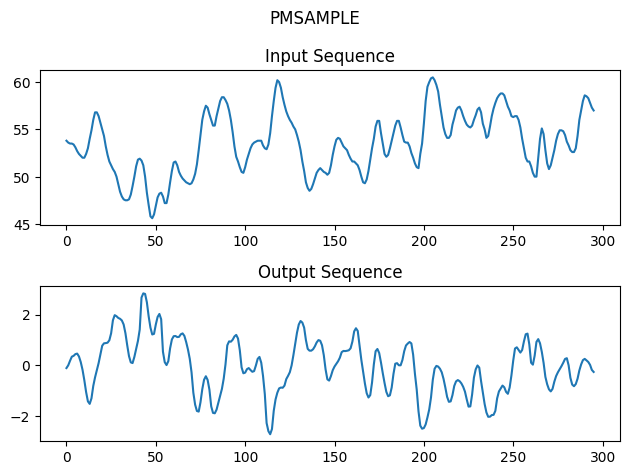

In [6]:
# Plot data

me = 'PMSAMPLE'

fig, ax = plt.subplots(2)
fig.suptitle (me)

ax[0].plot(y[0])
ax[0].set_title('Input Sequence')
ax[1].plot(u[0])
ax[1].set_title('Output Sequence')

plt.tight_layout()
plt.show()

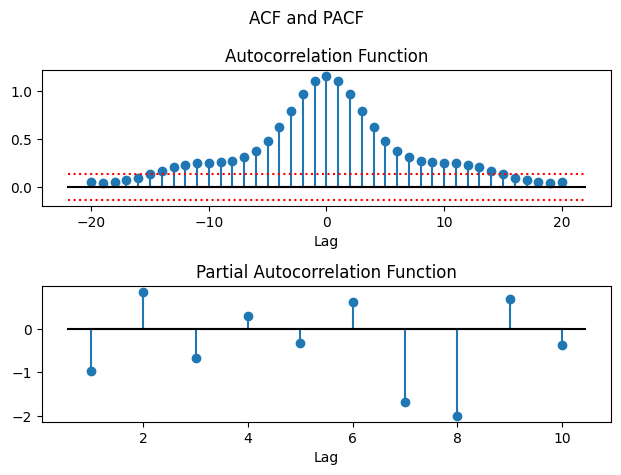

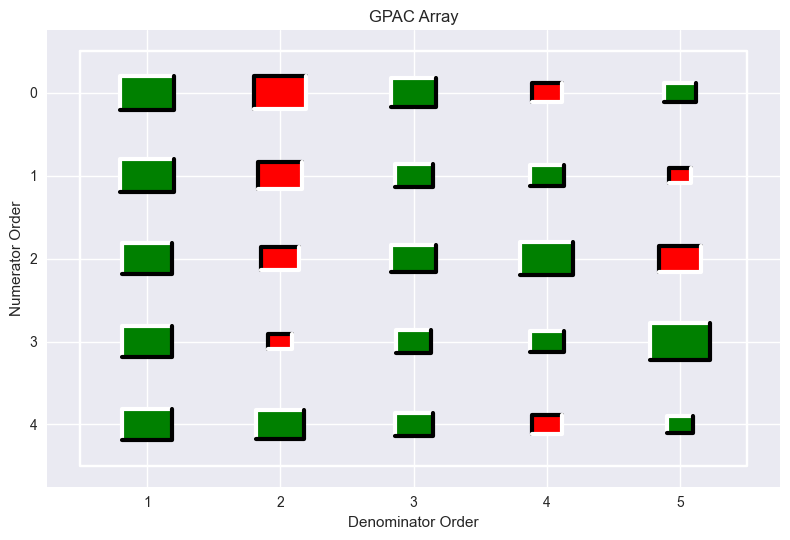

In [7]:
# Find the acf, pacf and gpac for the u sequence.

uacf,upacf,ugpac = xtimeseries.uniAnal(u,20,10,5,0,np.array([0]),np.array([]),1)

 It appears that sequence u might be estimated by an AR
 process.  Select the figure labeled "ACF and PACF" to see
 the autocorrelation function and partial autocorrelation
 function.  The autocorrelation function is infinite, like
 damped exponentials.  The partial autocorrelation function
 approximately cuts off after lag 3.  The figure labeled
 "GPAC Array" displays the GPAC for this data. The first row
 contains small values begining in the fourth column,
 also indicating it might be an AR process.

 Find the impulse response between u and y, the residual
 autocorrelation, and the GPAC array for each.  In the
 figure labeled 'Impulse Response and Residual ACF', the
 impulse response shows 3 delays between u and y.  From the
 figure named 'G & H GPAC Array', the H gpac showed that H may
 be approximated with numerator order of 0 and denominator
 order of 2.

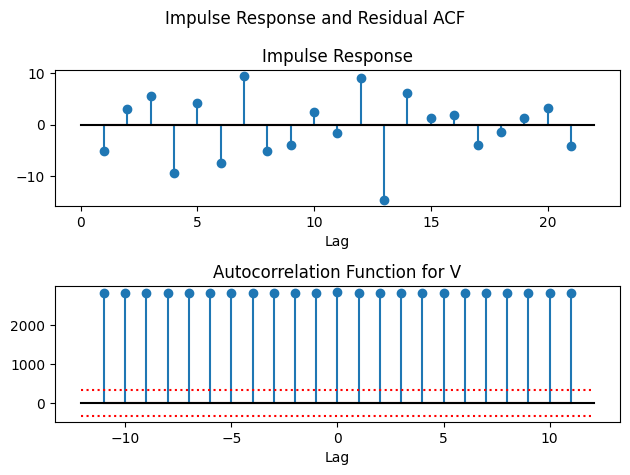

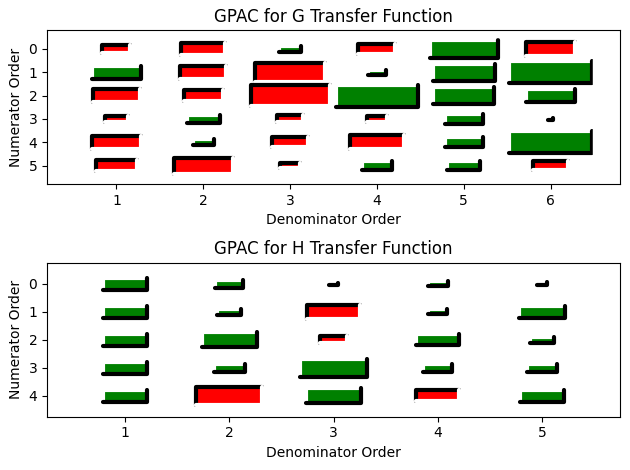

In [8]:
g,rv,g_gpac,h_gpac = xtimeseries.multiAnal(u,y,6,6)

 For the first prediction model of this data we will
 use the Box and Jenkins transfer function model.  The
 model is in the form
    y(t) = G u(t) + H e(t)
 where G is a transfer function with numerator pmod.b
 and denominator pmod.f, H is a transfer function with
 numerator pmod.c and denominator pmod.d.  String SPEC
 specifies a BJTF to be estimated, and possible
 orders of numerators and denominators in G and H.

In [19]:
spec = {
    'models' : [{
    'type': 'bjtf',
    'nb' :[1,2],
    'nc' :[0],
    'nd' :[2],
    'nf' : [0,1],
    'delay' : [3],
    'diff' : [0] }]
}

y = res[0] - np.mean(res[0])
u = res[1] - np.mean(res[1])

y = y.reshape(1, -1)
u = u.reshape(1, -1)


In [22]:
estpmod = TS.selpmod.func_selpmod(spec,y,u)

Input may not be zero mean sequences.
Selecting the best BJTF prediction model
bjtf: Combination 1 out of 4 total.  aic = 0.6241346581499116, bic = 0.6740043805056423
Input may not be zero mean sequences.
bjtf: Combination 2 out of 4 total.  aic = 1.7148691748990457, bic = 1.777206327843709
Input may not be zero mean sequences.
bjtf: Combination 3 out of 4 total.  aic = 2.5984772215739906, bic = 2.6608143745186537
Input may not be zero mean sequences.
bjtf: Combination 4 out of 4 total.  aic = 2.7203921339197303, bic = 2.7951967174533263
